# Model Performance Evaluation Results

This notebook loads the results of model evaluation runs and visualizes the key performance metrics.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from IPython.display import display


# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
import sys
from pathlib import Path  # noqa: F811

# Resolve root directory path
current_dir = Path.cwd()
root_dir = current_dir.parents[1] if current_dir.name == "eval_performance" else current_dir

if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))
if str(root_dir.parent) not in sys.path:
    sys.path.append(str(root_dir.parent))

from helpers.df_helper import ModelStatsDisplayCols  # noqa: E402
from tailor_cv_eval.tools.eval_performance.run_all_models import RESULTS_DIR  # noqa: E402

csv_files = list(RESULTS_DIR.glob("model_comparison_*.csv"))

dfs = []
for csv_file in csv_files:
    # Extract run name from model_comparison_{run_name}.csv
    run_name = csv_file.stem.replace("model_comparison_", "")
    df_run = pd.read_csv(csv_file)
    df_run["Run Name"] = run_name
    dfs.append(df_run)

df_all = pd.concat(dfs, ignore_index=True)

# Define consistent color palette for models dynamically supporting any number of models
unique_models = sorted(df_all[ModelStatsDisplayCols.MODEL].unique())

display(df_all.head())

2026-07-06 11:00:47.067 | INFO     | config.config:load:388 - Loading configuration from /home/kirill/prj/gh/job-hunt/tools/py/config/config.yaml


,Model,Total Time (s),Load Time (s),Prompt Tokens,Gen Tokens,Gen Speed (t/s),Response Chars,Response Words,GPU Usage,GPU Info,Options,Run Name
0,qwen3.5:4b-q4_K_M,82.112409,6.348081,9481,6132,83.874443,5989,786,1.000000,3.76 GB / 3.76 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
1,qwen2.5:7b,24.002578,6.441369,9424,918,65.477436,3879,543,1.000000,5.98 GB / 5.98 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
2,deepseek-r1:8b,358.609218,5.698974,9397,2441,7.043466,8030,1151,0.640392,6.18 GB / 9.65 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
3,granite3.1-dense:8b,306.523667,6.265770,10320,1684,5.761818,6056,806,0.602879,6.11 GB / 10.14 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
4,nemotron-mini:4b-instruct-q8_0,9.481740,5.115262,4095,270,73.477525,1552,214,1.000000,3.91 GB / 3.91 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1


# Run names

> NOTE: check - not other runs should be presented otherwise data will be messed

In [3]:
pd.DataFrame(df_all["Run Name"].unique(), columns=["Run Name"])

,Run Name
0,m30_ctx32k_temp01_predneg1


# Check unique options

In [4]:
pd.DataFrame({ModelStatsDisplayCols.OPTIONS: df_all[ModelStatsDisplayCols.OPTIONS].unique()})

,Options
0,"ctx: 32768, pred: -1, temp: 0.1"


# Check unique models

In [18]:
pd.DataFrame({ModelStatsDisplayCols.MODEL: df_all[ModelStatsDisplayCols.MODEL].unique()}).sort_values(ModelStatsDisplayCols.MODEL).reset_index(drop=True)

,Model
0,codegemma:7b-code
1,deepseek-r1:1.5b
2,deepseek-r1:7b
3,deepseek-r1:8b
4,falcon3:7b
5,gemma2:9b-instruct-q5_K_M
6,gemma4:12b-it-qat
7,gemma4:e2b
8,gemma4:e2b-ctx16k
9,gemma4:e2b-ctx32k


# Check GPU performance

In [20]:
df_all = df_all.round(3)
non_100_gpu = (
    df_all[df_all[ModelStatsDisplayCols.GPU_USAGE] != 1.0]
    .sort_values([ModelStatsDisplayCols.GPU_USAGE])
    .reset_index(drop=True)
)
if not non_100_gpu.empty:
    display(
        non_100_gpu[
            [
                ModelStatsDisplayCols.MODEL,
                ModelStatsDisplayCols.GPU_USAGE,
                ModelStatsDisplayCols.GPU_INFO,
                ModelStatsDisplayCols.OPTIONS,
                "Run Name",
            ]
        ]
    )


,Model,GPU Usage,GPU Info,Options,Run Name
0,llama3.1:8b-instruct-q6_K,0.530,6.19 GB / 11.67 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
1,gemma2:9b-instruct-q5_K_M,0.595,5.27 GB / 8.84 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
2,granite3.1-dense:8b,0.603,6.11 GB / 10.14 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
3,codegemma:7b-code,0.637,6.22 GB / 9.76 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
4,deepseek-r1:8b,0.640,6.18 GB / 9.65 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
5,gemma4:12b-it-qat,0.697,5.57 GB / 7.99 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
6,llama3.1:8b-text-q4_K_M,0.712,6.31 GB / 8.87 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
7,llama3.1:8b,0.712,6.31 GB / 8.87 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
8,phi4-mini:3.8b-q8_0,0.717,6.23 GB / 8.68 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
9,qwen3.5:9b-q4_K_M,0.734,5.03 GB / 6.86 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1


## Model with 100% GPU

In [21]:
display(
    df_all[df_all[ModelStatsDisplayCols.GPU_USAGE] == 1.0]
    .sort_values([ModelStatsDisplayCols.GPU_USAGE, ModelStatsDisplayCols.GPU_INFO, ModelStatsDisplayCols.MODEL])
    .reset_index(drop=True)[
        [
            ModelStatsDisplayCols.MODEL,
            ModelStatsDisplayCols.GPU_USAGE,
            ModelStatsDisplayCols.GPU_INFO,
            ModelStatsDisplayCols.OPTIONS,
            "Run Name",
        ]
    ]
)

,Model,GPU Usage,GPU Info,Options,Run Name
0,gemma4:e2b,1.0,1.52 GB / 1.52 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
1,gemma4:e2b-ctx16k,1.0,1.52 GB / 1.52 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
2,gemma4:e2b-ctx32k,1.0,1.52 GB / 1.52 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
3,gemma4:e2b-it-qat,1.0,1.62 GB / 1.62 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
4,deepseek-r1:1.5b,1.0,1.97 GB / 1.97 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
5,gemma4:e4b-it-qat,1.0,2.80 GB / 2.80 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
6,qwen2.5-coder:3b,1.0,3.13 GB / 3.13 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
7,qwen3.5:4b-q4_K_M,1.0,3.76 GB / 3.76 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
8,nemotron-mini:4b-instruct-q8_0,1.0,3.91 GB / 3.91 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1
9,nemotron-3-nano:4b-q8_0,1.0,4.38 GB / 4.38 GB,"ctx: 32768, pred: -1, temp: 0.1",m30_ctx32k_temp01_predneg1


## Visualizations

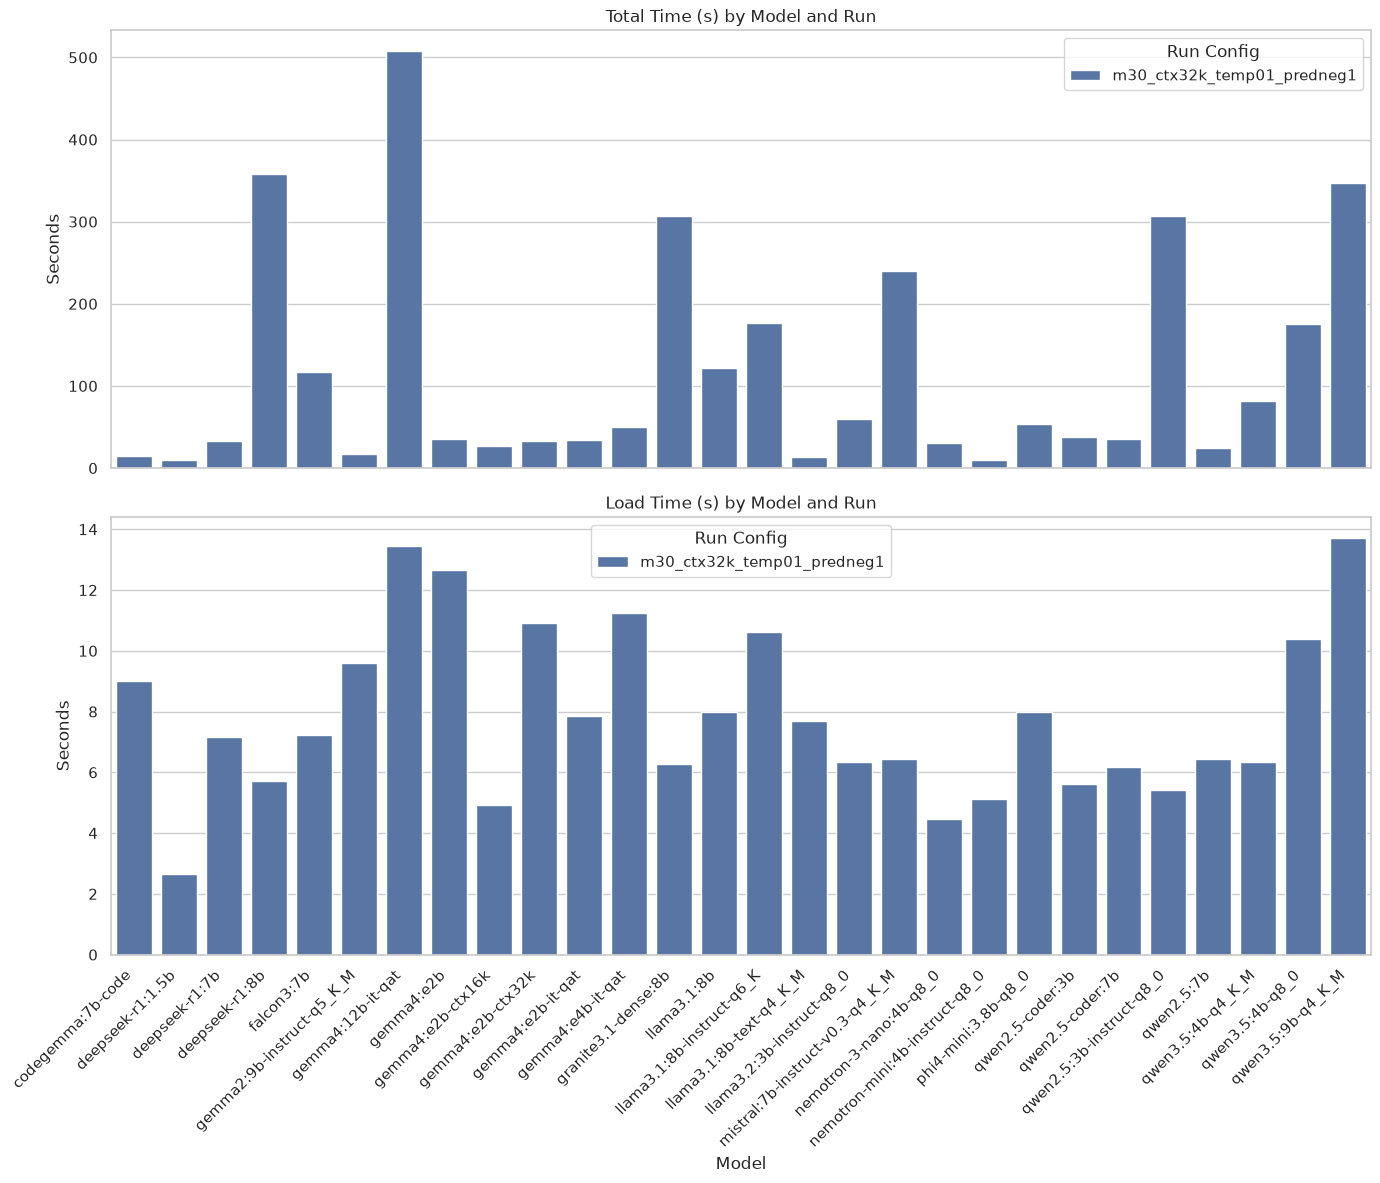

In [7]:
# 1. Total Time (s) and Load Time (s)
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

sns.barplot(
    ax=axes[0],
    data=df_all,
    x=ModelStatsDisplayCols.MODEL,
    y=ModelStatsDisplayCols.TOTAL_TIME,
    hue="Run Name",
    order=unique_models,
)
axes[0].set_title("Total Time (s) by Model and Run")
axes[0].set_ylabel("Seconds")
axes[0].legend(title="Run Config")

sns.barplot(
    ax=axes[1],
    data=df_all,
    x=ModelStatsDisplayCols.MODEL,
    y=ModelStatsDisplayCols.LOAD_TIME,
    hue="Run Name",
    order=unique_models,
)
axes[1].set_title("Load Time (s) by Model and Run")
axes[1].set_ylabel("Seconds")
axes[1].set_xlabel("Model")
axes[1].legend(title="Run Config")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

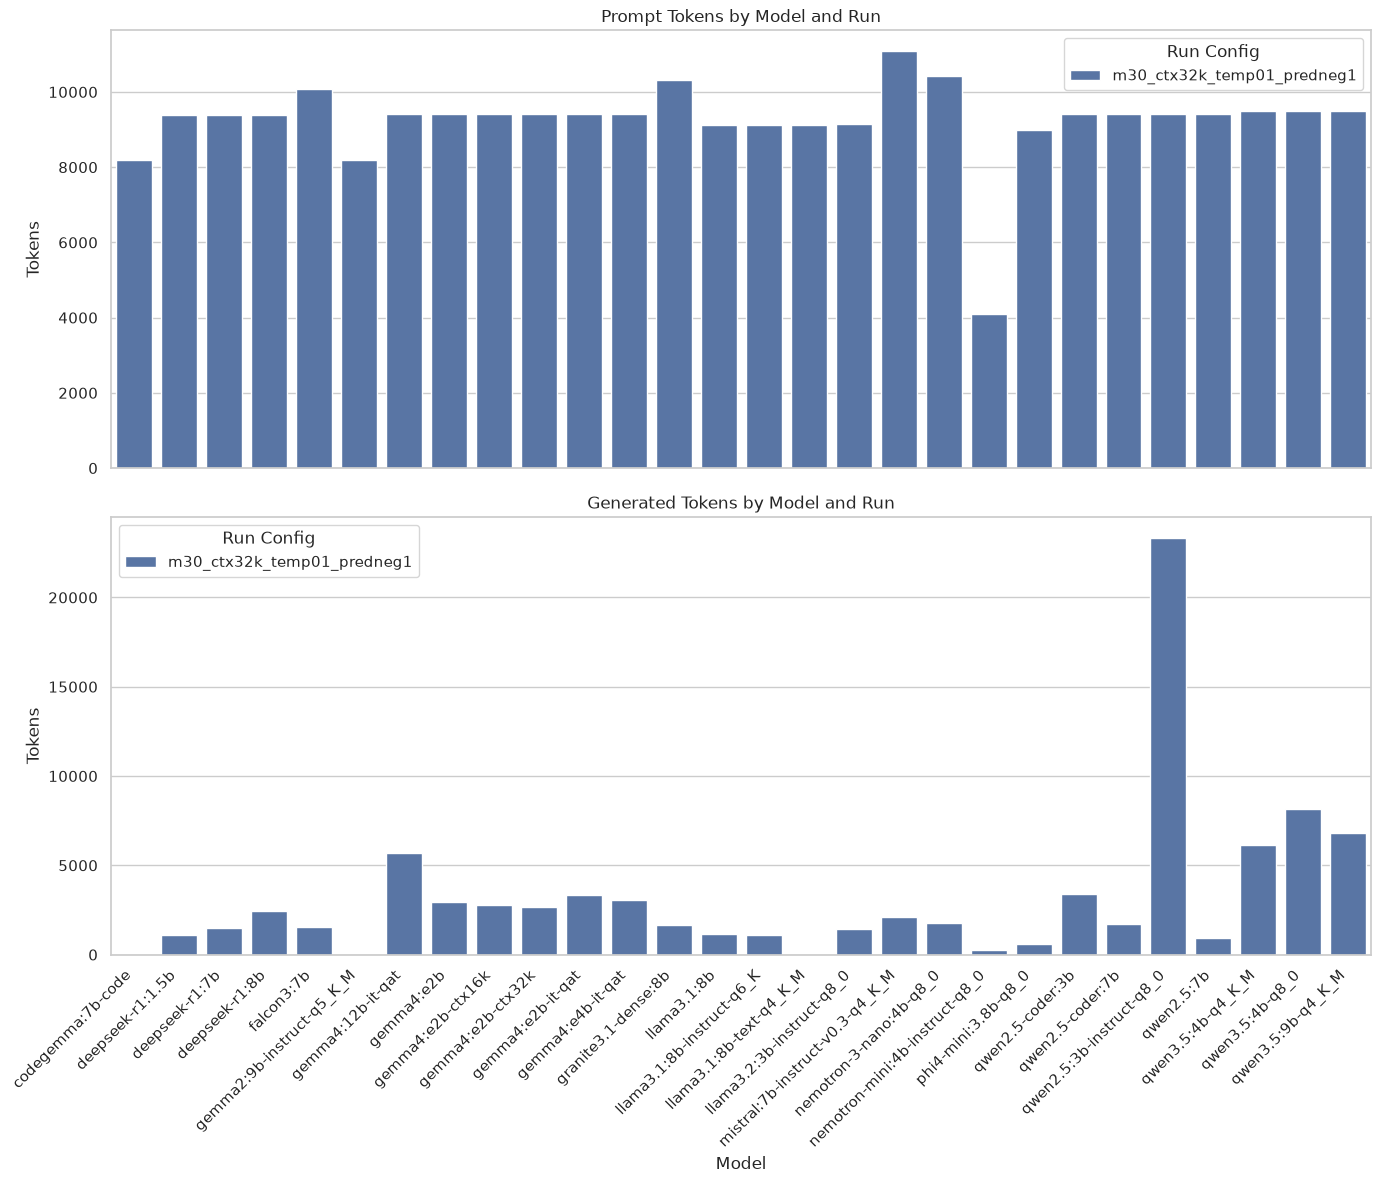

In [8]:
# 2. Prompt Tokens and Gen Tokens
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

sns.barplot(
    ax=axes[0],
    data=df_all,
    x=ModelStatsDisplayCols.MODEL,
    y=ModelStatsDisplayCols.PROMPT_TOKENS,
    hue="Run Name",
    order=unique_models,
)
axes[0].set_title("Prompt Tokens by Model and Run")
axes[0].set_ylabel("Tokens")
axes[0].legend(title="Run Config")

sns.barplot(
    ax=axes[1],
    data=df_all,
    x=ModelStatsDisplayCols.MODEL,
    y=ModelStatsDisplayCols.GEN_TOKENS,
    hue="Run Name",
    order=unique_models,
)
axes[1].set_title("Generated Tokens by Model and Run")
axes[1].set_ylabel("Tokens")
axes[1].set_xlabel("Model")
axes[1].legend(title="Run Config")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

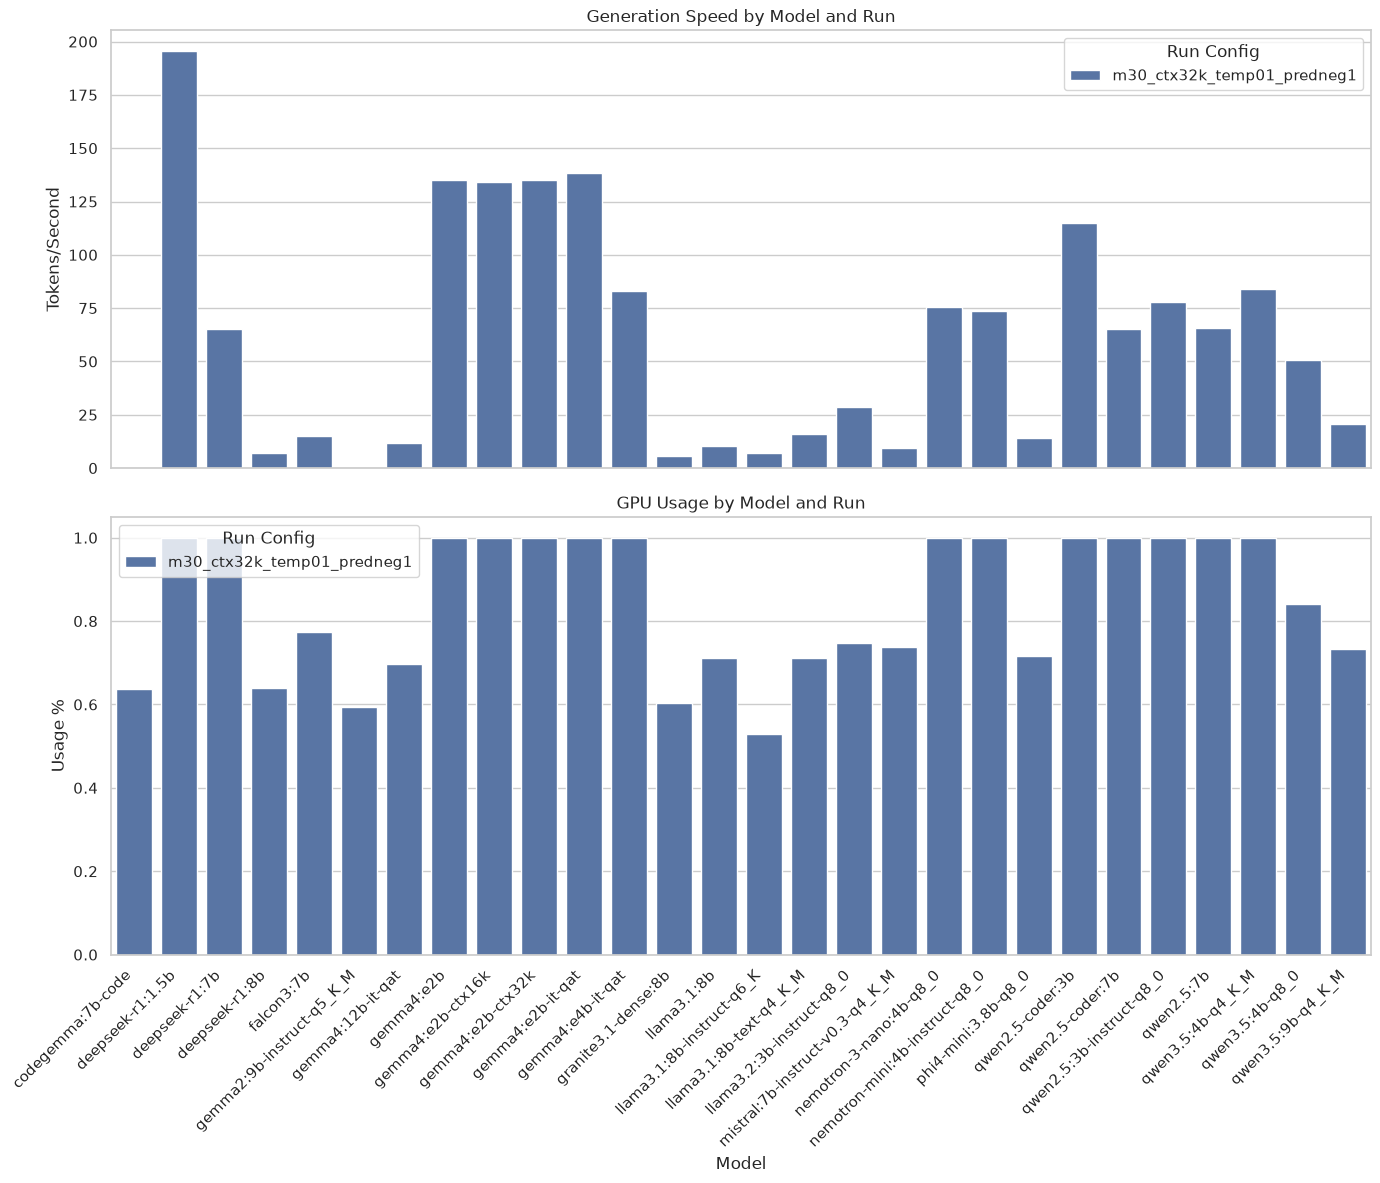

In [9]:
# 3. Gen Speed (t/s) and GPU Usage
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

sns.barplot(
    ax=axes[0],
    data=df_all,
    x=ModelStatsDisplayCols.MODEL,
    y=ModelStatsDisplayCols.GEN_SPEED,
    hue="Run Name",
    order=unique_models,
)
axes[0].set_title("Generation Speed by Model and Run")
axes[0].set_ylabel("Tokens/Second")
axes[0].legend(title="Run Config")

sns.barplot(
    ax=axes[1],
    data=df_all,
    x=ModelStatsDisplayCols.MODEL,
    y=ModelStatsDisplayCols.GPU_USAGE,
    hue="Run Name",
    order=unique_models,
)
axes[1].set_title("GPU Usage by Model and Run")
axes[1].set_ylabel("Usage %")
axes[1].set_xlabel("Model")
axes[1].legend(title="Run Config")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

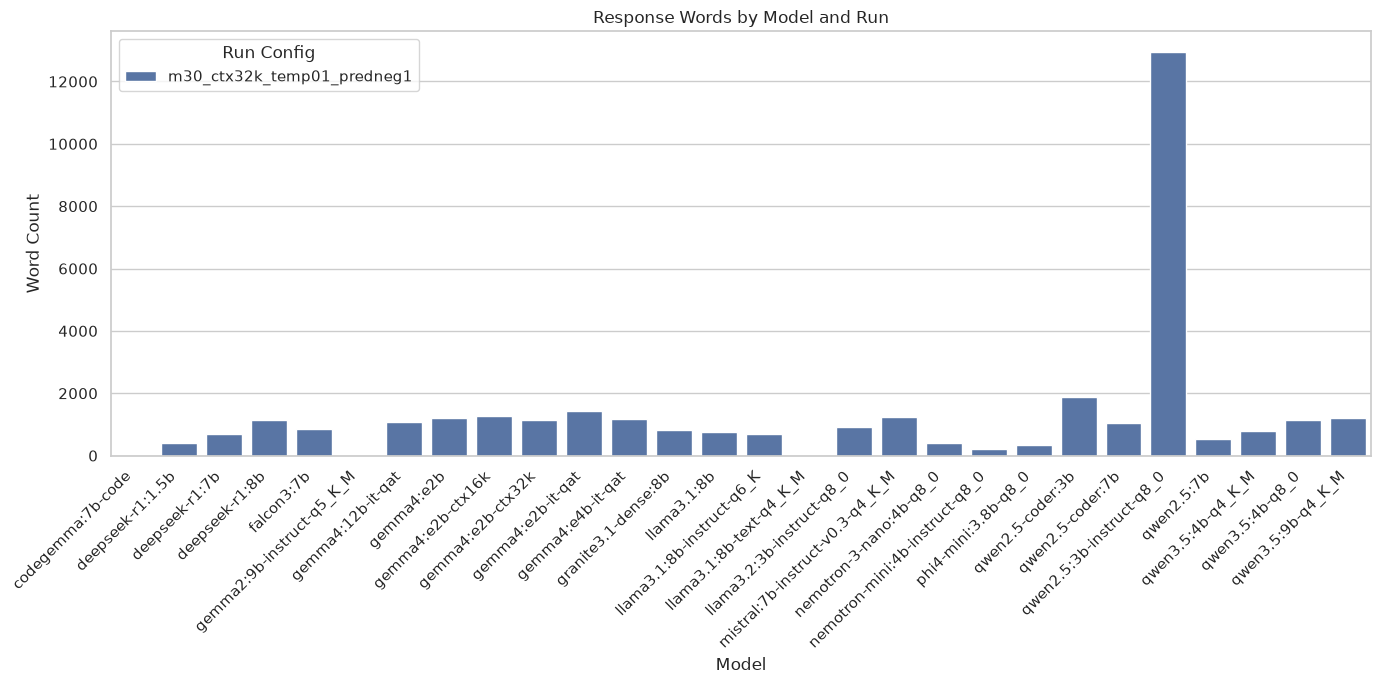

In [10]:
# 4. Response Words
plt.figure(figsize=(14, 7))
sns.barplot(
    data=df_all,
    x=ModelStatsDisplayCols.MODEL,
    y=ModelStatsDisplayCols.RESPONSE_WORDS,
    hue="Run Name",
    order=unique_models,
)
plt.title("Response Words by Model and Run")
plt.ylabel("Word Count")
plt.xlabel("Model")
plt.legend(title="Run Config")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [11]:
# Filter models with bad performance
df_filtered = df_all[
    (df_all[ModelStatsDisplayCols.GPU_USAGE] == 1.0) & (df_all[ModelStatsDisplayCols.GEN_SPEED] > 0)
].copy()

view_cols = [
    ModelStatsDisplayCols.MODEL,
    ModelStatsDisplayCols.OPTIONS,
    ModelStatsDisplayCols.TOTAL_TIME,
    ModelStatsDisplayCols.GEN_SPEED,
    ModelStatsDisplayCols.GEN_TOKENS,
    ModelStatsDisplayCols.RESPONSE_WORDS,
]
table_df = (
    df_filtered[view_cols]
    .sort_values([ModelStatsDisplayCols.GEN_TOKENS, ModelStatsDisplayCols.RESPONSE_WORDS], ascending=False)
    .reset_index(drop=True)
)
styled_df = table_df.style.background_gradient(
    cmap="RdYlGn",
    subset=[ModelStatsDisplayCols.GEN_TOKENS, ModelStatsDisplayCols.RESPONSE_WORDS, ModelStatsDisplayCols.GEN_SPEED],
).background_gradient(cmap="RdYlGn_r", subset=[ModelStatsDisplayCols.TOTAL_TIME])
display(styled_df)

,Model,Options,Total Time (s),Gen Speed (t/s),Gen Tokens,Response Words
0,qwen2.5:3b-instruct-q8_0,"ctx: 32768, pred: -1, temp: 0.1",306.843000,77.908000,23344,12961
1,qwen3.5:4b-q4_K_M,"ctx: 32768, pred: -1, temp: 0.1",82.112000,83.874000,6132,786
2,qwen2.5-coder:3b,"ctx: 32768, pred: -1, temp: 0.1",37.232000,115.096000,3403,1878
3,gemma4:e2b-it-qat,"ctx: 32768, pred: -1, temp: 0.1",33.593000,138.420000,3362,1421
4,gemma4:e4b-it-qat,"ctx: 32768, pred: -1, temp: 0.1",50.181000,82.804000,3031,1162
5,gemma4:e2b,"ctx: 32768, pred: -1, temp: 0.1",35.925000,135.100000,2939,1219
6,gemma4:e2b-ctx16k,"ctx: 32768, pred: -1, temp: 0.1",26.932000,134.280000,2765,1261
7,gemma4:e2b-ctx32k,"ctx: 32768, pred: -1, temp: 0.1",32.641000,135.164000,2691,1156
8,nemotron-3-nano:4b-q8_0,"ctx: 32768, pred: -1, temp: 0.1",30.914000,75.759000,1784,413
9,qwen2.5-coder:7b,"ctx: 32768, pred: -1, temp: 0.1",35.497000,65.345000,1687,1056


# Top one based on MinMaxScaler

In [12]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = table_df.copy()

scaler = MinMaxScaler()
metrics = [
    ModelStatsDisplayCols.TOTAL_TIME,
    ModelStatsDisplayCols.GEN_SPEED,
    ModelStatsDisplayCols.GEN_TOKENS,
    ModelStatsDisplayCols.RESPONSE_WORDS,
]
df_norm = pd.DataFrame(scaler.fit_transform(df[metrics]), columns=metrics)
df_norm[ModelStatsDisplayCols.TOTAL_TIME] = 1 - df_norm[ModelStatsDisplayCols.TOTAL_TIME]

weights = {
    ModelStatsDisplayCols.TOTAL_TIME: 0.20,
    ModelStatsDisplayCols.GEN_SPEED: 0.10,
    ModelStatsDisplayCols.GEN_TOKENS: 0.30,
    ModelStatsDisplayCols.RESPONSE_WORDS: 0.40,
}

CONST_SCALER_SCORE = "Scaler Score"

df[CONST_SCALER_SCORE] = (
    df_norm[ModelStatsDisplayCols.TOTAL_TIME] * weights[ModelStatsDisplayCols.TOTAL_TIME]
    + df_norm[ModelStatsDisplayCols.GEN_SPEED] * weights[ModelStatsDisplayCols.GEN_SPEED]
    + df_norm[ModelStatsDisplayCols.GEN_TOKENS] * weights[ModelStatsDisplayCols.GEN_TOKENS]
    + df_norm[ModelStatsDisplayCols.RESPONSE_WORDS] * weights[ModelStatsDisplayCols.RESPONSE_WORDS]
)

df_scaler = df.sort_values(by=CONST_SCALER_SCORE, ascending=False).reset_index(drop=True)
df_scaler[
    [
        ModelStatsDisplayCols.MODEL,
        ModelStatsDisplayCols.OPTIONS,
        CONST_SCALER_SCORE,
        ModelStatsDisplayCols.TOTAL_TIME,
        ModelStatsDisplayCols.GEN_SPEED,
        ModelStatsDisplayCols.GEN_TOKENS,
        ModelStatsDisplayCols.RESPONSE_WORDS,
    ]
].head()

,Model,Options,Scaler Score,Total Time (s),Gen Speed (t/s),Gen Tokens,Response Words
0,qwen2.5:3b-instruct-q8_0,"ctx: 32768, pred: -1, temp: 0.1",0.709653,306.843,77.908,23344,12961
1,gemma4:e2b-it-qat,"ctx: 32768, pred: -1, temp: 0.1",0.317905,33.593,138.420,3362,1421
2,deepseek-r1:1.5b,"ctx: 32768, pred: -1, temp: 0.1",0.316659,9.319,195.497,1100,401
3,qwen2.5-coder:3b,"ctx: 32768, pred: -1, temp: 0.1",0.312412,37.232,115.096,3403,1878
4,gemma4:e2b-ctx16k,"ctx: 32768, pred: -1, temp: 0.1",0.306419,26.932,134.280,2765,1261


# Top ones based on TOPSIS

In [13]:
import skcriteria as skc
from skcriteria.madm import similarity
from skcriteria.preprocessing import scalers

df = table_df.copy()

# Set objectives: min (-1), max (1), max (1), max (1)
matrix = skc.mkdm(
    df[
        [
            ModelStatsDisplayCols.TOTAL_TIME,
            ModelStatsDisplayCols.GEN_SPEED,
            ModelStatsDisplayCols.GEN_TOKENS,
            ModelStatsDisplayCols.RESPONSE_WORDS,
        ]
    ].values,
    objectives=[-1, 1, 1, 1],
    alternatives=df[ModelStatsDisplayCols.MODEL].values,
    criteria=["Time", "Speed", "Tokens", "Words"],
)

# Apply TOPSIS
scaler = scalers.VectorScaler(target="matrix")
decider = similarity.TOPSIS()
decision = decider.evaluate(scaler.transform(matrix))

CONST_TOPSIS_RANK = "TOPSIS Rank"
CONST_TOPSIS_SCORE = "TOPSIS Score"

# 1. Extract the rankings from the decision object (1 is the best)
df[CONST_TOPSIS_RANK] = decision.rank_

# 2. Extract the actual similarity score (how close it is to the "Ideal" model)
# Higher score is better (ranges from 0 to 1)
df[CONST_TOPSIS_SCORE] = decision.e_.similarity

# 3. Sort your dataframe so the #1 ranked model is at the top
df_topsis = df.sort_values(by=CONST_TOPSIS_RANK)

# 4. Use Jupyter's rich display instead of print() for a beautiful HTML table
display(
    df_topsis[
        [
            CONST_TOPSIS_RANK,
            CONST_TOPSIS_SCORE,
            ModelStatsDisplayCols.MODEL,
            ModelStatsDisplayCols.OPTIONS,
            ModelStatsDisplayCols.TOTAL_TIME,
            ModelStatsDisplayCols.GEN_SPEED,
            ModelStatsDisplayCols.GEN_TOKENS,
            ModelStatsDisplayCols.RESPONSE_WORDS,
        ]
    ].head()
)

/home/kirill/prj/gh/job-hunt/tools/py/.venv/lib/python3.12/site-packages/skcriteria/madm.py:35: SKCriteriaDeprecationWarning: 'skcriteria.madm' module is deprecated, use 'skcriteria.agg' instead
  utils.deprecate.warn(**__deprecation_conf)
/home/kirill/prj/gh/job-hunt/tools/py/.venv/lib/python3.12/site-packages/skcriteria/agg/similarity.py:124: UserWarning: Although TOPSIS can operate with minimization objectives, this is not recommended. Consider reversing the weights for these cases.
  warnings.warn(


,TOPSIS Rank,TOPSIS Score,Model,Options,Total Time (s),Gen Speed (t/s),Gen Tokens,Response Words
0,1,0.584702,qwen2.5:3b-instruct-q8_0,"ctx: 32768, pred: -1, temp: 0.1",306.843,77.908,23344,12961
11,2,0.424224,deepseek-r1:1.5b,"ctx: 32768, pred: -1, temp: 0.1",9.319,195.497,1100,401
3,3,0.419257,gemma4:e2b-it-qat,"ctx: 32768, pred: -1, temp: 0.1",33.593,138.420,3362,1421
2,4,0.418080,qwen2.5-coder:3b,"ctx: 32768, pred: -1, temp: 0.1",37.232,115.096,3403,1878
6,5,0.417887,gemma4:e2b-ctx16k,"ctx: 32768, pred: -1, temp: 0.1",26.932,134.280,2765,1261


# Best models

In [14]:
result = pd.merge(
    df_scaler,
    df_topsis,
    on=[
        ModelStatsDisplayCols.MODEL,
        ModelStatsDisplayCols.OPTIONS,
    ],
)[
    [
        ModelStatsDisplayCols.MODEL,
        ModelStatsDisplayCols.OPTIONS,
        CONST_TOPSIS_RANK,
        CONST_TOPSIS_SCORE,
        CONST_SCALER_SCORE,
    ]
]

CONST_COMBINED_RANK = "Combined Rank"
CONST_COMBINED_SCORE = "Combined Score"

df_combined = result.copy()

matrix = skc.mkdm(
    matrix=df_combined[[CONST_TOPSIS_SCORE, CONST_SCALER_SCORE]].values,
    objectives=[1, 1],
    criteria=[CONST_TOPSIS_SCORE, CONST_SCALER_SCORE],
)

scaler = scalers.VectorScaler(target="matrix")
decider = similarity.TOPSIS()
decision = decider.evaluate(scaler.transform(matrix))

df_combined[CONST_COMBINED_RANK] = decision.rank_
df_combined[CONST_COMBINED_SCORE] = decision.e_.similarity

df_final_topsis = df_combined.sort_values(by=CONST_COMBINED_RANK)
styled_df = (
    df_final_topsis.head(10)
    .style.background_gradient(
        cmap="RdYlGn",
        subset=[CONST_TOPSIS_SCORE, CONST_SCALER_SCORE, CONST_COMBINED_SCORE],
    )
    .background_gradient(cmap="RdYlGn_r", subset=[CONST_COMBINED_RANK, CONST_TOPSIS_RANK])
)
display(styled_df)

,Model,Options,TOPSIS Rank,TOPSIS Score,Scaler Score,Combined Rank,Combined Score
0,qwen2.5:3b-instruct-q8_0,"ctx: 32768, pred: -1, temp: 0.1",1,0.584702,0.709653,1,1.000000
1,gemma4:e2b-it-qat,"ctx: 32768, pred: -1, temp: 0.1",3,0.419257,0.317905,2,0.220768
2,deepseek-r1:1.5b,"ctx: 32768, pred: -1, temp: 0.1",2,0.424224,0.316659,3,0.220715
3,qwen2.5-coder:3b,"ctx: 32768, pred: -1, temp: 0.1",4,0.418080,0.312412,4,0.210332
4,gemma4:e2b-ctx16k,"ctx: 32768, pred: -1, temp: 0.1",5,0.417887,0.306419,5,0.199435
5,gemma4:e2b,"ctx: 32768, pred: -1, temp: 0.1",7,0.410951,0.301948,6,0.188389
6,gemma4:e2b-ctx32k,"ctx: 32768, pred: -1, temp: 0.1",6,0.411360,0.299004,7,0.183216
7,qwen3.5:4b-q4_K_M,"ctx: 32768, pred: -1, temp: 0.1",14,0.375629,0.259469,8,0.100377
8,gemma4:e4b-it-qat,"ctx: 32768, pred: -1, temp: 0.1",12,0.388407,0.251592,9,0.087946
9,qwen2.5-coder:7b,"ctx: 32768, pred: -1, temp: 0.1",10,0.390193,0.227248,10,0.045168


# Summary

Top models:
- gemma4:e2b
- gemma4:e4b-it-qat

Slow model - quality should be check:
- qwen3.5:4b-q8_0

llama3.2:3b-instruct-q8_0 - generates too few output tokens

Here are best options to try:
- for `num_ctx=16384` use `num_predict: -1` and `temperature: 0.0` or `temperature: 0.1`
